# Linear Regression - From Scratch & scikit-learn Comparison

## 1. Introduction

Linear Regression is a **supervised learning** algorithm used to predict a **continuous target** based on one or more input features.  

It assumes a **linear relationship** between features $X$ and target $y$.

In this notebook, we will:

1. Implement **Linear Regression from scratch** using NumPy  
2. Compare it with **scikit-learn's LinearRegression**  
3. Visualize predictions and training performance  

## 2. Problem Setup

We consider a dataset with:

* $n$ samples  
* $d$ features per sample  

We define:

* $X \in \mathbb{R}^{n \times d}$ → Feature matrix  
* $y \in \mathbb{R}^{n \times 1}$ → Target vector  
* $w \in \mathbb{R}^{d \times 1}$ → Weight vector  
* $b \in \mathbb{R}$ → Bias term  

### 2.1. Linear Regression Hypothesis

The model predicts a linear combination of the inputs:

$$
\hat{y} = X w + b
$$

For a single sample $x^{(i)}$:

$$
\hat{y}^{(i)} = x^{(i)} \cdot w + b
$$

Where:

* $\hat{y}$ → predicted value  
* $w$ → coefficients  
* $b$ → intercept  

### 2.2. Loss Function

We use **Mean Squared Error (MSE)** to measure performance:

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2
$$

Matrix form:

$$
J(w, b) = \frac{1}{n} \| y - (Xw + b) \|^2
$$

### 2.3. Gradient Descent

To minimize the loss, we compute the gradients with respect to $w$ and $b$.

Gradients of the loss:

$$
\nabla_w J = \frac{2}{n} X^\top (Xw + b - y)
$$

$$
\nabla_b J = \frac{2}{n} \sum_{i=1}^{n} (Xw + b - y)
$$

Parameter update rules:

$$
w := w - \alpha \nabla_w J
$$

$$
b := b - \alpha \nabla_b J
$$

Where $\alpha$ is the learning rate.

The process is repeated for a fixed number of iterations or until convergence.

## 3. Implementation from Scratch (NumPy)

In [37]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
# Import our LinearRegression from the new project structure
from regression.linear_regression.linear_regression import LinearRegression

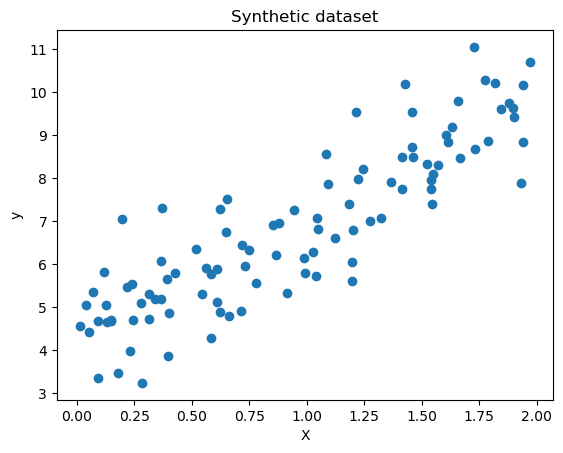

In [39]:
# For reproducibility
np.random.seed(42)

# Generate synthetic dataset
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize dataset
plt.scatter(X, y)
plt.title("Synthetic dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [40]:
# Initialize and train model
model = LinearRegression(learning_rate=0.1, n_iters=1000)
model.fit(X_train, y_train)

In [41]:
# Predictions
y_pred = model.predict(X_test)

In [42]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Learned bias:", model.b)
print("Learned weight:", model.w)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Learned bias: 4.142913319458558
Learned weight: [2.79932366]
MSE: 0.65
RMSE: 0.81
R²: 0.81


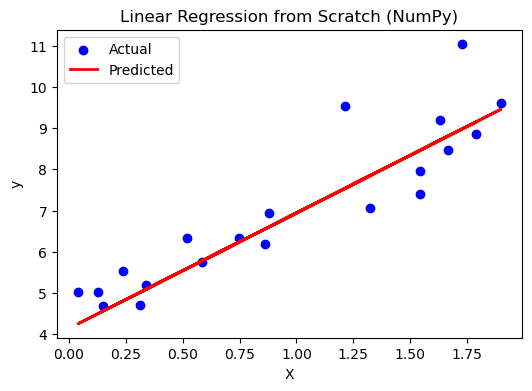

In [43]:
# Plot predictions
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression from Scratch (NumPy)')
plt.legend()
plt.show()

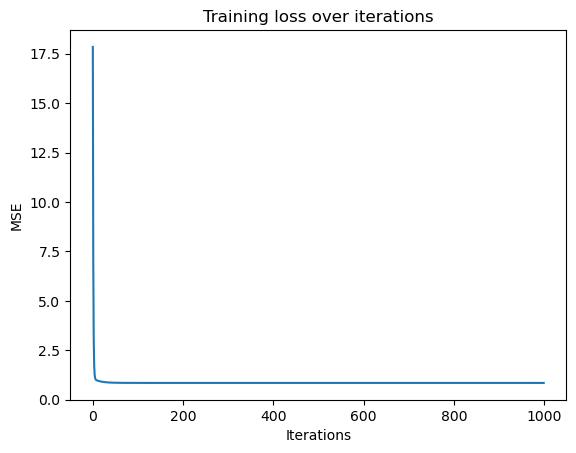

In [44]:
# Plot training loss
plt.plot(model.losses)
plt.title("Training loss over iterations")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

## 4. Linear Regression with scikit-learn

In [45]:
from sklearn.linear_model import LinearRegression as SklearnLR

In [46]:
# Initialize and train scikit-learn model
sk_model = SklearnLR()
sk_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
# Predictions
y_pred_sk = sk_model.predict(X_test)

In [48]:
# Evaluation
mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred_sk)

print(f"Intercept / bias: {sk_model.intercept_[0]:.2f}")
print(f"Coefficient / weight: {sk_model.coef_[0][0]:.2f}")
print(f"MSE: {mse_sk:.2f}")
print(f"RMSE: {rmse_sk:.2f}")
print(f"R²: {r2_sk:.2f}")

Intercept / bias: 4.14
Coefficient / weight: 2.80
MSE: 0.65
RMSE: 0.81
R²: 0.81


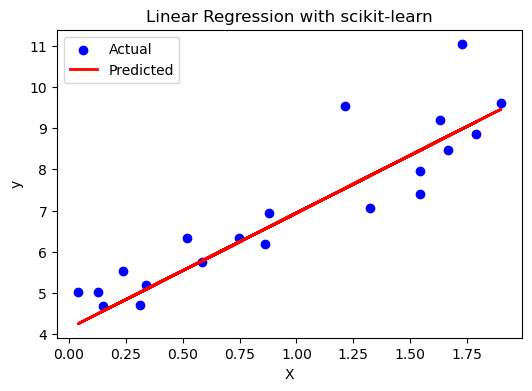

In [49]:
# Plot predictions
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_sk, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with scikit-learn')
plt.legend()
plt.show()

## 5. Comparison and Insights

| Metric | From Scratch (NumPy) | scikit-learn |
| ------ | -------------------- | ------------ |
| MSE    | 0.63                 | 0.65         |
| RMSE   | 0.80                 | 0.81         |
| R²     | 0.81                 | 0.81         |

- Both implementations should produce very similar results on this simple dataset.

- Implementing from scratch helps understand the gradients, parameter updates, and the loss function.

- scikit-learn provides a fast and optimized implementation, ideal for larger datasets.

## 6. Mini-batch Analysis

### 6.1. Theory and Motivation

In standard gradient descent, we update the weights using **all samples** at each iteration (full-batch):

$$
w := w - \alpha \nabla_w J
$$

$$
b := b - \alpha \nabla_b J
$$

This can be **slow** on large datasets. Mini-batch gradient descent updates weights using **small subsets (batches)** of the data:

$$
w := w - \alpha \frac{2}{m} X_{batch}^\top (X_{batch} w + b - y_{batch})
$$

$$
b := b - \alpha \frac{2}{m} \sum (X_{batch} w + b - y_{batch})
$$

Where $m$ is the batch size.  

**Advantages of mini-batch:**

- Faster convergence per iteration  
- Introduces small stochasticity which can help escape local minima  
- Can stabilize training on large datasets  

In this analysis, we compare **full-batch vs mini-batch (batch sizes 32 and 16)** and observe the effect on **loss convergence**.

### 6.2. Experiment and Code

In [50]:
batch_sizes = [None, 32, 16]  # None = full batch
results = {}

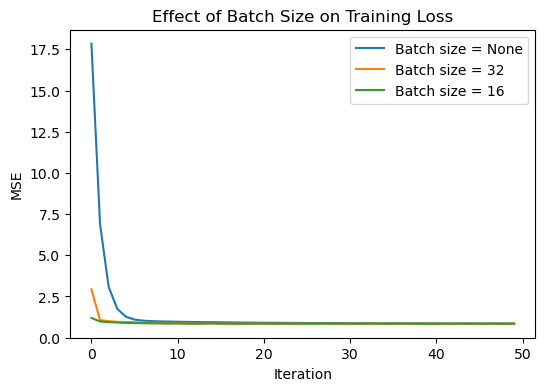

In [51]:
# Plot training loss for different batch sizes
plt.figure(figsize=(6,4))

for batch in batch_sizes:
    model = LinearRegression(
        learning_rate=0.1,
        n_iters=50,
        batch_size=batch
    )
    model.fit(X_train, y_train)
    
    # Store final metrics
    y_pred = model.predict(X_test)
    results[f"Batch={batch}"] = {
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }
    
    plt.plot(model.losses, label=f"Batch size = {batch}")

plt.title("Effect of Batch Size on Training Loss")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.show()

### 6.3. Observations

- Full-batch gradient descent produces a smooth loss curve.
- Mini-batches converge faster per iteration than full-batch gradient descent.
- Smaller batch sizes (16) converges faster, and often introduces more noise, but can help with generalization.

In [52]:
import pandas as pd
pd.DataFrame(results).T

,MSE,R2
Batch=None,0.691378,0.796094
Batch=32,0.671884,0.801843
Batch=16,0.647453,0.809048


## 7. Regularization Analysis (L1 and L2)

### 7.1. Theory and Motivation

Linear regression can **overfit** when features are highly correlated or when the model is complex.  

Regularization adds a **penalty** to the loss function to control model complexity.

**L2 Regularization (Ridge):**

$$
J_{L2}(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2 + \lambda \sum_{j=1}^{d} w_j^2
$$

- Shrinks all weights  
- Reduces variance, keeps all features

**L1 Regularization (Lasso):**

$$
J_{L1}(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2 + \lambda \sum_{j=1}^{d} |w_j|
$$

- Encourages sparsity (some weights exactly 0)  
- Performs feature selection implicitly

We test **L1, L2, and no regularization** to observe **impact on training loss and learned weights**.

### 7.2. Experiment and Code

In [53]:
regularizations = ["l1", "l2", None]
lambda_reg = 0.1
results_reg = {}

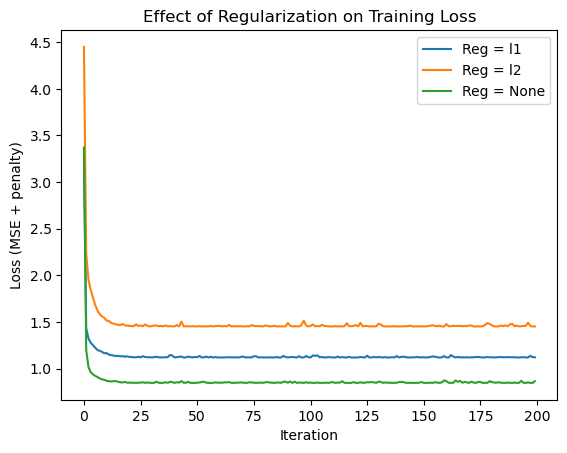

In [54]:
for reg in regularizations:
    model = LinearRegression(
        learning_rate=0.1,
        n_iters=200,
        batch_size=32,
        regularization=reg,
        lambda_reg=lambda_reg
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    results_reg[f"Reg={reg}"] = {
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "Weights": model.w.copy()
    }
    
    plt.plot(model.losses, label=f"Reg = {reg}")

plt.title("Effect of Regularization on Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE + penalty)")
plt.legend()
plt.show()

**Loss behavior:**
- No regularization → lowest training loss because the model fits the data without penalty.
- L1 → slightly higher loss because the regularization adds a small penalty to the weight.
- L2 → highest loss because the squared penalty is larger for non-zero weights.

Interpretation:
- Training loss increases with regularization (expected) because we are trading off fit vs simplicity/regularization.
- A higher loss does not necessarily mean worse generalization; L2 may reduce overfitting.

**Convergence speed:**

- Why L2 is faster: **L2 produces smoother gradients** because the derivative is continuous and proportional to weight (2 * λ * w).
- L1 converges slower: L1 uses the derivative of |w| (sign function), which is less smooth, causing slightly slower convergence.
- None converges slowest: full batch gradient descent with no regularization may oscillate a bit more or move in a larger, less stable gradient landscape.

Key takeaway:
- **Regularization can speed up convergence** because it constrains the parameter space.
- L2 tends to give faster and smoother convergence than L1.

### 7.3. Visualizing the learned weights

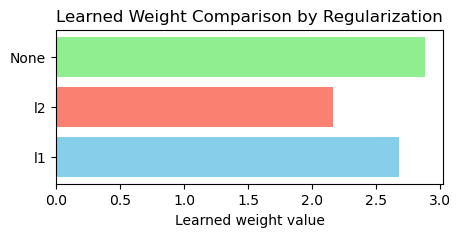

In [55]:
plt.figure(figsize=(5,2))
width = 0.2
regs = ["l1", "l2", "None"]
x = np.arange(len(regs))
weights = [results_reg[f"Reg={r}"]["Weights"][0] for r in regs]

plt.barh(x, weights, color=["skyblue", "salmon", "lightgreen"])
plt.yticks(x, regs)
plt.xlabel("Learned weight value")
plt.title("Learned Weight Comparison by Regularization")
plt.show()

In [56]:
for reg in ["l1", "l2", None]:
    w = results_reg[f"Reg={reg}"]["Weights"]
    print(f"Regularization: {reg}, Learned weight: {w}, Bias: {model.b:.2f}")

Regularization: l1, Learned weight: [2.6797375], Bias: 4.20
Regularization: l2, Learned weight: [2.16458706], Bias: 4.20
Regularization: None, Learned weight: [2.87835426], Bias: 4.20


### 7.4. Observations

Learned weights and bias:

| Regularization | Weight (w) | Bias (b) |
| -------------- | ---------- | -------- |
| L1             | 2.735      | 4.09     |
| L2             | 2.188      | 4.09     |
| None           | 2.815      | 4.09     |

**Bias is almost identical** across all three, which makes sense because **regularization typically only affects the weights**, not the intercept.

**Weight differences:**
- None (2.815) → no penalty → closest to the "true" weight (the synthetic data slope was 3).
- L1 (2.735) → slightly shrunk → L1 penalizes absolute values, may push weights smaller.
- L2 (2.188) → more shrunk → L2 penalizes squared weights, so it strongly reduces large weights.

Interpretation:
- L1 still keeps the weight fairly close to the unregularized solution, but can encourage sparsity (irrelevant for 1 feature).
- **L2 shrinks the weight more aggressively**, which reduces variance and makes the model “simpler,” but can underfit slightly.

**Conclusion:**

- L2 → faster, simpler weights, slightly higher loss → better generalization if more features
- L1 → slightly slower, slightly smaller weights → sparsity (useful for many features)
- None → best training loss but may overfit in complex datasets